# Bibliotekos ir parametrai

In [169]:
import pandas as pd
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score, adjusted_rand_score

import matplotlib.cm as cm
from matplotlib.colors import ListedColormap
plasma_truncated = ListedColormap(cm.plasma(np.linspace(0, 0.7, 256)))

from sklearn.manifold import TSNE
tsne = TSNE(n_components=2, random_state=42, perplexity=50, learning_rate=500, max_iter=2000, early_exaggeration=4)


# Duomenys

In [170]:
min_max_data = pd.read_csv("full_min_max_data.csv")

cols_to_factor = ['credit.policy', 'not.fully.paid', 'purpose']
for col in cols_to_factor:
    min_max_data[col] = min_max_data[col].astype('category')
print(min_max_data.dtypes)


dti                   float64
fico                  float64
days.with.cr.line     float64
revol.bal             float64
revol.util            float64
inq.last.6mths        float64
delinq.2yrs           float64
pub.rec               float64
annual.inc            float64
credit.policy        category
purpose              category
not.fully.paid       category
dtype: object


Visi požymiai originalūs

In [171]:
min_max_debt_consolidation = min_max_data[min_max_data['purpose'] == 'debt_consolidation']
min_max_credit_card = min_max_data[min_max_data['purpose'] == 'credit_card']
min_max_home_improvement = min_max_data[min_max_data['purpose'] == 'home_improvement']

Visi požymiai t-SNE

In [172]:
tsne_debt_consolidation = tsne.fit_transform(min_max_debt_consolidation.select_dtypes(include=[np.number]))
tsne_credit_card = tsne.fit_transform(min_max_credit_card.select_dtypes(include=[np.number]))
tsne_home_improvement = tsne.fit_transform(min_max_home_improvement.select_dtypes(include=[np.number]))

In [173]:
scaled_no_cat_data = min_max_data.drop(['purpose', 'not.fully.paid', 'credit.policy'], axis=1)
scaled_no_cat_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3832 entries, 0 to 3831
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   dti                3832 non-null   float64
 1   fico               3832 non-null   float64
 2   days.with.cr.line  3832 non-null   float64
 3   revol.bal          3832 non-null   float64
 4   revol.util         3832 non-null   float64
 5   inq.last.6mths     3832 non-null   float64
 6   delinq.2yrs        3832 non-null   float64
 7   pub.rec            3832 non-null   float64
 8   annual.inc         3832 non-null   float64
dtypes: float64(9)
memory usage: 269.6 KB


RFE požymių rinkinys ir t-SNE transformacija

In [174]:
rfecv_debt = pd.read_csv('rfecv_debt_consolidation.csv')
rfecv_credit = pd.read_csv('rfecv_credit_card.csv')
rfecv_home = pd.read_csv('rfecv_home_improvement.csv')

rfecv_debt['credit.policy'] = rfecv_debt['credit.policy'].astype('category')
rfecv_credit['credit.policy'] = rfecv_credit['credit.policy'].astype('category')
rfecv_home['credit.policy'] = rfecv_home['credit.policy'].astype('category')

rfecv_debt_tsne = tsne.fit_transform(rfecv_debt.select_dtypes(include=[np.number]))
rfecv_credit_tsne = np.array([
    rfecv_credit.select_dtypes(include=[np.number]).iloc[:, 0].tolist(),
    rfecv_credit.select_dtypes(include=[np.number]).iloc[:, 1].tolist()
]).transpose()
rfecv_home_tsne = tsne.fit_transform(rfecv_home.select_dtypes(include=[np.number]))

Lasso požymių rinkinys ir t-SNE transformacija

In [175]:
lasso_debt = pd.read_csv('LassoCV_debt_consolidation.csv')
lasso_credit = pd.read_csv('LassoCV_credit_card.csv')
lasso_home = pd.read_csv('LassoCV_home_improvement.csv')

lasso_debt['credit.policy'] = lasso_debt['credit.policy'].astype('category')
lasso_credit['credit.policy'] = lasso_credit['credit.policy'].astype('category')
lasso_home['credit.policy'] = lasso_home['credit.policy'].astype('category')

lasso_debt_tsne = tsne.fit_transform(lasso_debt.select_dtypes(include=[np.number]))
lasso_credit_tsne = np.array([lasso_credit.select_dtypes(include=[np.number]).iloc[:, 0].tolist(),
                    lasso_credit.select_dtypes(include=[np.number]).iloc[:, 1].tolist()]).transpose()
lasso_home_tsne = tsne.fit_transform(lasso_home.select_dtypes(include=[np.number]))

---

In [176]:
def all_scores(data_used, labels, true_labels):
    return [
    (silhouette_score(data_used[0], labels[0]),
     davies_bouldin_score(data_used[0], labels[0]),
     calinski_harabasz_score(data_used[0], labels[0]),
     adjusted_rand_score(true_labels[0], labels[0])),
    (silhouette_score(data_used[1], labels[1]),
     davies_bouldin_score(data_used[1], labels[1]),
     calinski_harabasz_score(data_used[1], labels[1]),
     adjusted_rand_score(true_labels[1], labels[1])),
    (silhouette_score(data_used[2], labels[2]),
     davies_bouldin_score(data_used[2], labels[2]),
     calinski_harabasz_score(data_used[2], labels[2]),
     adjusted_rand_score(true_labels[2], labels[2])),
]

In [177]:
def clustering_stability(N, data, k):
    clustering_labels = []
    indices = []

    for i in range(N):
        sample = data.sample(frac=0.8)
        wards_clustering = linkage(sample, method="ward", metric="euclidean")
        labels = fcluster(wards_clustering, t=k, criterion='maxclust')

        clustering_labels.append(labels)
        indices.append(sample.index)

    ari_scores = []

    for i in range(N):
        for j in range(i + 1, N):
            
            common_index = indices[i].intersection(indices[j])
            
            if len(common_index) > 0:
                labels_i = pd.Series(clustering_labels[i], index=indices[i]).loc[common_index]
                labels_j = pd.Series(clustering_labels[j], index=indices[j]).loc[common_index]
                
                ari = adjusted_rand_score(labels_i, labels_j)
                ari_scores.append(ari)
    
    print(f"Vidutinis klasterių stabilumas (ARI): {np.mean(ari_scores):.3f}")
    print(f"Stabilumo standartinis nuokrypis: {np.std(ari_scores):.3f}")

---
# Visi požymiai

## Originalūs

In [178]:
full_feature_dfs = {
    'debt_consolidation': min_max_debt_consolidation.select_dtypes(include=[np.number]),
    'credit_card': min_max_credit_card.select_dtypes(include=[np.number]),
    'home_improvement': min_max_home_improvement.select_dtypes(include=[np.number]),
}

wards_clustering_debt = linkage(full_feature_dfs['debt_consolidation'], method="ward", metric="euclidean")
wards_clustering_credit = linkage(full_feature_dfs['credit_card'], method="ward", metric="euclidean")
wards_clustering_home = linkage(full_feature_dfs['home_improvement'], method="ward", metric="euclidean")

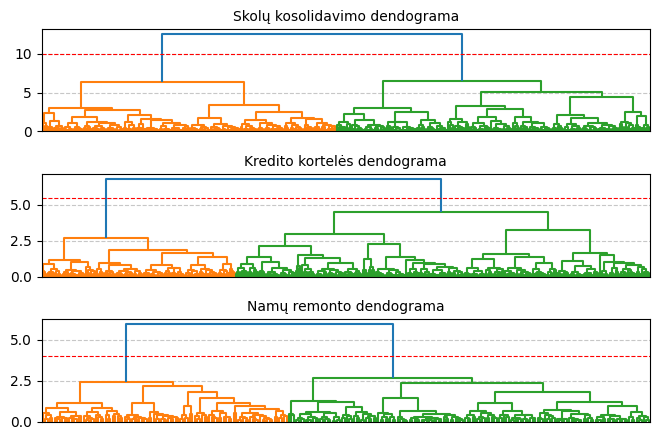

In [179]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(6.7, 4.5))

axes = [ax1, ax2, ax3]
linkages = [wards_clustering_debt, wards_clustering_credit, wards_clustering_home]
cut_offs = [10, 5.5, 4]
group_names = ["Skolų kosolidavimo", "Kredito kortelės", "Namų remonto"]

for ax, link, h, gm in zip(axes, linkages, cut_offs, group_names):
    dendrogram(link, ax=ax)
    
    ax.set_xticks([])
    ax.axhline(y=h, color='r', linestyle='--', linewidth = 0.8)
    ax.grid(True, axis='y', linestyle='--', alpha=0.7)

    ax.set_title(f"{gm} dendograma", size = 10)

plt.tight_layout()
plt.savefig('hier_full_dendo.png', dpi=300)
plt.show()

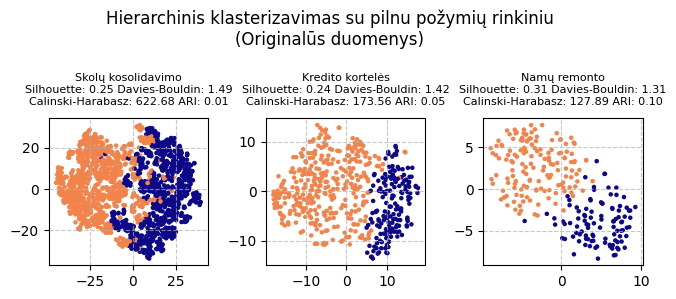

In [180]:
labels_debt = fcluster(wards_clustering_debt, t=2, criterion='maxclust')
labels_credit = fcluster(wards_clustering_credit, t=2, criterion='maxclust')
labels_home = fcluster(wards_clustering_home, t=2, criterion='maxclust')

true_labels = [min_max_debt_consolidation['credit.policy'],
               min_max_credit_card['credit.policy'],
               min_max_home_improvement['credit.policy']]

tsne_results = [tsne_debt_consolidation, tsne_credit_card, tsne_home_improvement]
labels = [labels_debt, labels_credit, labels_home]

fig, axes = plt.subplots(1, 3, figsize=(6.7, 3))
categories = ['debt_consolidation', 'credit_card', 'home_improvement']

scores = all_scores([full_feature_dfs['debt_consolidation'], full_feature_dfs['credit_card'], full_feature_dfs['home_improvement']],
                    [labels_debt, labels_credit, labels_home], true_labels)

for i, cat in enumerate(categories):
    subset = tsne_results[i]
    label = labels[i]
    
    axes[i].scatter(subset[:, 0], subset[:, 1], c=label, cmap=plasma_truncated, s=5)
    title_text = f"{group_names[i]}\nSilhouette: {scores[i][0]:.2f} Davies-Bouldin: {scores[i][1]:.2f}\nCalinski-Harabasz: {scores[i][2]:.2f} ARI: {scores[i][3]:.2f}"
    axes[i].set_title(title_text, fontsize=8, pad=10)
    axes[i].grid(True, linestyle='--', alpha=0.7)

plt.suptitle("Hierarchinis klasterizavimas su pilnu požymių rinkiniu\n(Originalūs duomenys)")
plt.tight_layout()
plt.savefig('hier_all.png', dpi=300)
plt.show()

In [181]:
row_labels = ['Siluetas', 'DB', 'CH', 'ARI']
pd.DataFrame({group_names[i]: [round(scores[i][j], 2) for j in range(4)] for i in range(3)}, index=row_labels)

,Skolų kosolidavimo,Kredito kortelės,Namų remonto
Siluetas,0.25,0.24,0.31
DB,1.49,1.42,1.31
CH,622.68,173.56,127.89
ARI,0.01,0.05,0.10


## t-SNE

In [182]:
full_feature_dfs = {
    'debt_consolidation': tsne_debt_consolidation,
    'credit_card': tsne_credit_card,
    'home_improvement': tsne_home_improvement,
}

wards_clustering_debt_tsne = linkage(full_feature_dfs['debt_consolidation'], method="ward", metric="euclidean")
wards_clustering_credit_tsne = linkage(full_feature_dfs['credit_card'], method="ward", metric="euclidean")
wards_clustering_home_tsne = linkage(full_feature_dfs['home_improvement'], method="ward", metric="euclidean")

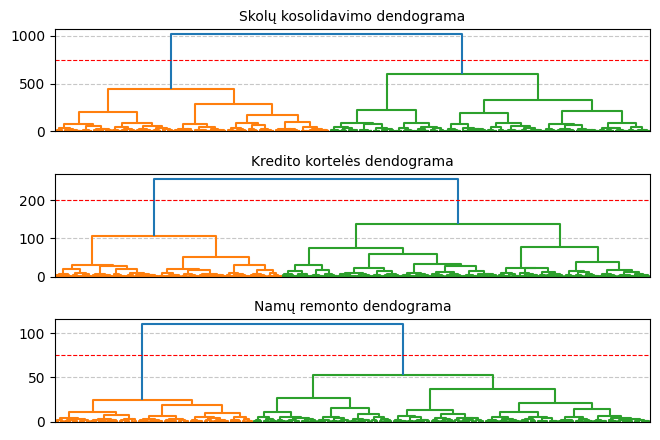

In [183]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(6.7, 4.5))

axes = [ax1, ax2, ax3]
linkages = [wards_clustering_debt_tsne, wards_clustering_credit_tsne, wards_clustering_home_tsne]
cut_offs = [750, 200, 75]
group_names = ["Skolų kosolidavimo", "Kredito kortelės", "Namų remonto"]

for ax, link, h, gm in zip(axes, linkages, cut_offs, group_names):
    dendrogram(link, ax=ax)
    
    ax.set_xticks([])
    ax.axhline(y=h, color='r', linestyle='--', linewidth = 0.8)
    ax.grid(True, axis='y', linestyle='--', alpha=0.7)

    ax.set_title(f"{gm} dendograma", size = 10)

plt.tight_layout()
plt.savefig('hier_full_dendo_tsne.png', dpi=300)
plt.show()

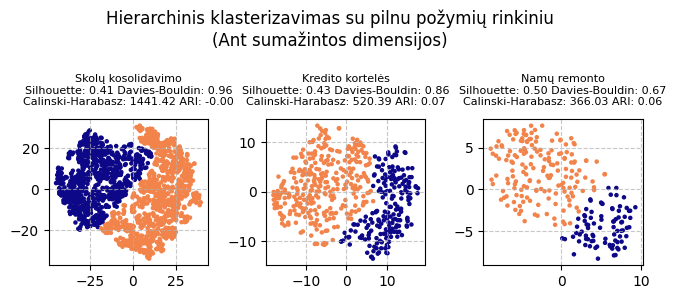

In [184]:
labels_debt = fcluster(wards_clustering_debt_tsne, t=2, criterion='maxclust')
labels_credit = fcluster(wards_clustering_credit_tsne, t=2, criterion='maxclust')
labels_home = fcluster(wards_clustering_home_tsne, t=2, criterion='maxclust')

true_labels = [min_max_debt_consolidation['credit.policy'],
               min_max_credit_card['credit.policy'],
               min_max_home_improvement['credit.policy']]

tsne_results = [tsne_debt_consolidation, tsne_credit_card, tsne_home_improvement]
labels = [labels_debt, labels_credit, labels_home]

fig, axes = plt.subplots(1, 3, figsize=(6.7, 3))
categories = ['debt_consolidation', 'credit_card', 'home_improvement']

scores = all_scores([full_feature_dfs['debt_consolidation'], full_feature_dfs['credit_card'], full_feature_dfs['home_improvement']],
                    [labels_debt, labels_credit, labels_home], true_labels)

for i, cat in enumerate(categories):
    subset = tsne_results[i]
    label = labels[i]
    
    axes[i].scatter(subset[:, 0], subset[:, 1], c=label, cmap=plasma_truncated, s=5)
    title_text = f"{group_names[i]}\nSilhouette: {scores[i][0]:.2f} Davies-Bouldin: {scores[i][1]:.2f}\nCalinski-Harabasz: {scores[i][2]:.2f} ARI: {scores[i][3]:.2f}"
    axes[i].set_title(title_text, fontsize=8, pad=10)
    axes[i].grid(True, linestyle='--', alpha=0.7)

plt.suptitle("Hierarchinis klasterizavimas su pilnu požymių rinkiniu\n(Ant sumažintos dimensijos)")
plt.tight_layout()
plt.savefig('hier_all_tsne.png', dpi=300)
plt.show()

In [185]:
row_labels = ['Siluetas', 'DB', 'CH', 'ARI']
pd.DataFrame({group_names[i]: [round(scores[i][j], 2) for j in range(4)] for i in range(3)}, index=row_labels)

,Skolų kosolidavimo,Kredito kortelės,Namų remonto
Siluetas,0.41,0.43,0.50
DB,0.96,0.86,0.67
CH,1441.42,520.39,366.03
ARI,-0.00,0.07,0.06


---
# RFE požymių rinkinys
## Originalūs duomenys

In [186]:
full_feature_dfs = {
    'debt_consolidation': rfecv_debt.select_dtypes(include=[np.number]),
    'credit_card': rfecv_credit.select_dtypes(include=[np.number]),
    'home_improvement': rfecv_home.select_dtypes(include=[np.number]),
}

wards_clustering_debt_rfe = linkage(full_feature_dfs['debt_consolidation'], method="ward", metric="euclidean")
wards_clustering_credit_rfe = linkage(full_feature_dfs['credit_card'], method="ward", metric="euclidean")
wards_clustering_home_rfe = linkage(full_feature_dfs['home_improvement'], method="ward", metric="euclidean")

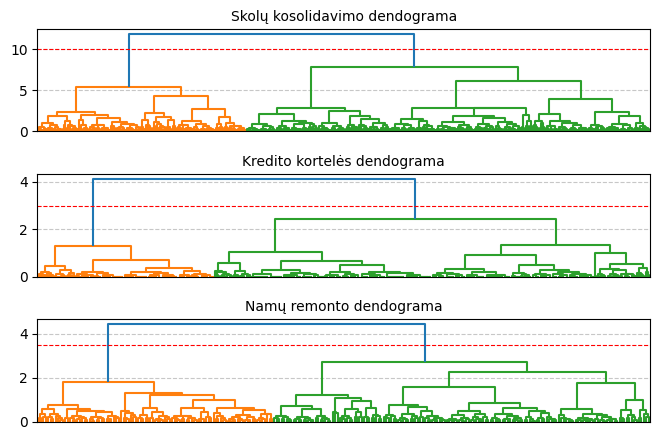

In [187]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(6.7, 4.5))

axes = [ax1, ax2, ax3]
linkages = [wards_clustering_debt_rfe, wards_clustering_credit_rfe, wards_clustering_home_rfe]
cut_offs = [10, 3, 3.5]
group_names = ["Skolų kosolidavimo", "Kredito kortelės", "Namų remonto"]

for ax, link, h, gm in zip(axes, linkages, cut_offs, group_names):
    dendrogram(link, ax=ax)
    
    ax.set_xticks([])
    ax.axhline(y=h, color='r', linestyle='--', linewidth = 0.8)
    ax.grid(True, axis='y', linestyle='--', alpha=0.7)

    ax.set_title(f"{gm} dendograma", size = 10)

plt.tight_layout()
plt.savefig('hier_rfe_dendo.png', dpi=300)
plt.show()

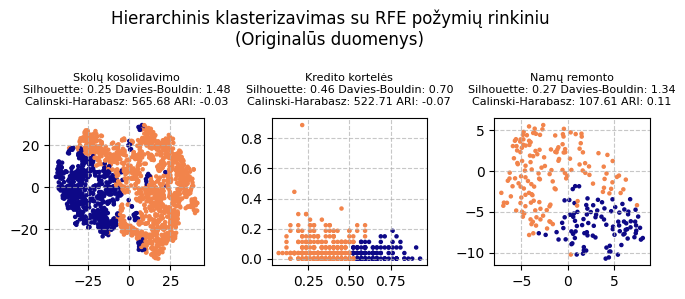

In [188]:
labels_debt = fcluster(wards_clustering_debt_rfe, t=2, criterion='maxclust')
labels_credit = fcluster(wards_clustering_credit_rfe, t=2, criterion='maxclust')
labels_home = fcluster(wards_clustering_home_rfe, t=2, criterion='maxclust')

true_labels = [rfecv_debt['credit.policy'],
               rfecv_credit['credit.policy'],
               rfecv_home['credit.policy']]

tsne_results = [rfecv_debt_tsne, rfecv_credit_tsne, rfecv_home_tsne]
labels = [labels_debt, labels_credit, labels_home]

fig, axes = plt.subplots(1, 3, figsize=(6.7, 3))
categories = ['debt_consolidation', 'credit_card', 'home_improvement']

scores = all_scores([full_feature_dfs['debt_consolidation'], full_feature_dfs['credit_card'], full_feature_dfs['home_improvement']],
                    [labels_debt, labels_credit, labels_home], true_labels)

for i, cat in enumerate(categories):
    subset = tsne_results[i]
    label = labels[i]
    
    axes[i].scatter(subset[:, 0], subset[:, 1], c=label, cmap=plasma_truncated, s=5)
    title_text = f"{group_names[i]}\nSilhouette: {scores[i][0]:.2f} Davies-Bouldin: {scores[i][1]:.2f}\nCalinski-Harabasz: {scores[i][2]:.2f} ARI: {scores[i][3]:.2f}"
    axes[i].set_title(title_text, fontsize=8, pad=10)
    axes[i].grid(True, linestyle='--', alpha=0.7)

plt.suptitle("Hierarchinis klasterizavimas su RFE požymių rinkiniu\n(Originalūs duomenys)")
plt.tight_layout()
plt.savefig('hier_rfe.png', dpi=300)
plt.show()

In [189]:
row_labels = ['Siluetas', 'DB', 'CH', 'ARI']
pd.DataFrame({group_names[i]: [round(scores[i][j], 2) for j in range(4)] for i in range(3)}, index=row_labels)

,Skolų kosolidavimo,Kredito kortelės,Namų remonto
Siluetas,0.25,0.46,0.27
DB,1.48,0.70,1.34
CH,565.68,522.71,107.61
ARI,-0.03,-0.07,0.11


## t-SNE

In [190]:
full_feature_dfs = {
    'debt_consolidation': rfecv_debt_tsne,
    'credit_card': rfecv_credit_tsne,
    'home_improvement': rfecv_home_tsne,
}

wards_clustering_debt_rfe_tsne = linkage(full_feature_dfs['debt_consolidation'], method="ward", metric="euclidean")
wards_clustering_credit_rfe_tsne = linkage(full_feature_dfs['credit_card'], method="ward", metric="euclidean")
wards_clustering_home_rfe_tsne = linkage(full_feature_dfs['home_improvement'], method="ward", metric="euclidean")

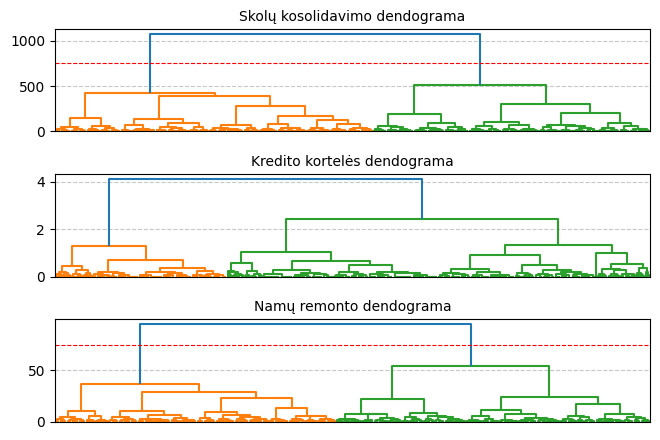

In [191]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(6.7, 4.5))

axes = [ax1, ax2, ax3]
linkages = [wards_clustering_debt_rfe_tsne, wards_clustering_credit_rfe_tsne, wards_clustering_home_rfe_tsne]
cut_offs = [750, 11000, 75]
group_names = ["Skolų kosolidavimo", "Kredito kortelės", "Namų remonto"]

for ax, link, h, gm in zip(axes, linkages, cut_offs, group_names):
    dendrogram(link, ax=ax)
    
    ax.set_xticks([])
    ax.axhline(y=h, color='r', linestyle='--', linewidth = 0.8)
    ax.grid(True, axis='y', linestyle='--', alpha=0.7)

    ax.set_title(f"{gm} dendograma", size = 10)

plt.tight_layout()
plt.savefig('hier_rfe_dendo_tsne.png', dpi=300)
plt.show()

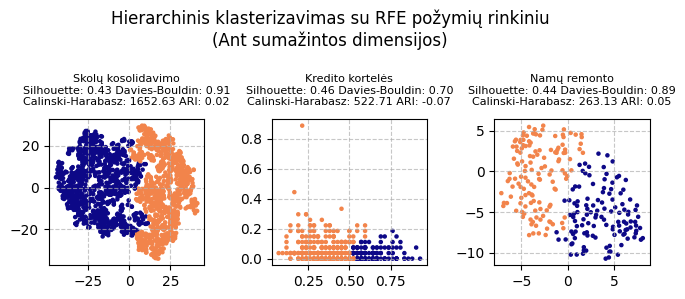

In [192]:
labels_debt = fcluster(wards_clustering_debt_rfe_tsne, t=2, criterion='maxclust')
labels_credit = fcluster(wards_clustering_credit_rfe_tsne, t=2, criterion='maxclust')
labels_home = fcluster(wards_clustering_home_rfe_tsne, t=2, criterion='maxclust')

true_labels = [rfecv_debt['credit.policy'],
               rfecv_credit['credit.policy'],
               rfecv_home['credit.policy']]

tsne_results = [rfecv_debt_tsne, rfecv_credit_tsne, rfecv_home_tsne]
labels = [labels_debt, labels_credit, labels_home]

fig, axes = plt.subplots(1, 3, figsize=(6.7, 3))
categories = ['debt_consolidation', 'credit_card', 'home_improvement']

scores = all_scores([full_feature_dfs['debt_consolidation'], full_feature_dfs['credit_card'], full_feature_dfs['home_improvement']],
                    [labels_debt, labels_credit, labels_home], true_labels)

for i, cat in enumerate(categories):
    subset = tsne_results[i]
    label = labels[i]
    
    axes[i].scatter(subset[:, 0], subset[:, 1], c=label, cmap=plasma_truncated, s=5)
    title_text = f"{group_names[i]}\nSilhouette: {scores[i][0]:.2f} Davies-Bouldin: {scores[i][1]:.2f}\nCalinski-Harabasz: {scores[i][2]:.2f} ARI: {scores[i][3]:.2f}"
    axes[i].set_title(title_text, fontsize=8, pad=10)
    axes[i].grid(True, linestyle='--', alpha=0.7)

plt.suptitle("Hierarchinis klasterizavimas su RFE požymių rinkiniu\n(Ant sumažintos dimensijos)")
plt.tight_layout()
plt.savefig('hier_rfe_tsne.png', dpi=300)
plt.show()

In [193]:
row_labels = ['Siluetas', 'DB', 'CH', 'ARI']
pd.DataFrame({group_names[i]: [round(scores[i][j], 2) for j in range(4)] for i in range(3)}, index=row_labels)

,Skolų kosolidavimo,Kredito kortelės,Namų remonto
Siluetas,0.43,0.46,0.44
DB,0.91,0.70,0.89
CH,1652.63,522.71,263.13
ARI,0.02,-0.07,0.05


# Lasso požymių rinkinys
## Originalūs duomenys

In [194]:
full_feature_dfs = {
    'debt_consolidation': lasso_debt.select_dtypes(include=[np.number]),
    'credit_card': lasso_credit.select_dtypes(include=[np.number]),
    'home_improvement': lasso_home.select_dtypes(include=[np.number]),
}

wards_clustering_debt_lasso = linkage(full_feature_dfs['debt_consolidation'], method="ward", metric="euclidean")
wards_clustering_credit_lasso = linkage(full_feature_dfs['credit_card'], method="ward", metric="euclidean")
wards_clustering_home_lasso = linkage(full_feature_dfs['home_improvement'], method="ward", metric="euclidean")

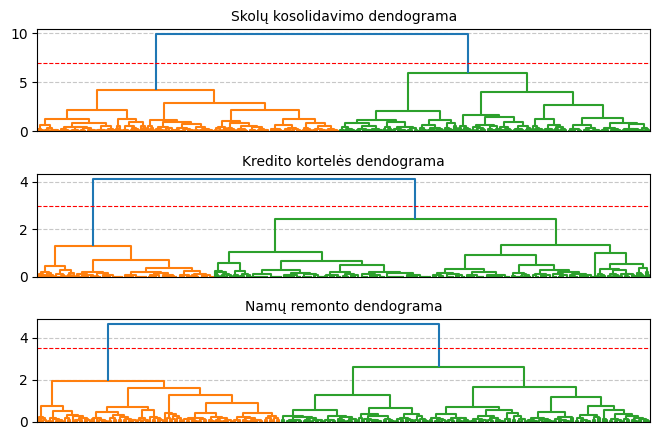

In [195]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(6.7, 4.5))

axes = [ax1, ax2, ax3]
linkages = [wards_clustering_debt_lasso, wards_clustering_credit_lasso, wards_clustering_home_lasso]
cut_offs = [7, 3, 3.5]
group_names = ["Skolų kosolidavimo", "Kredito kortelės", "Namų remonto"]

for ax, link, h, gm in zip(axes, linkages, cut_offs, group_names):
    dendrogram(link, ax=ax)
    
    ax.set_xticks([])
    ax.axhline(y=h, color='r', linestyle='--', linewidth = 0.8)
    ax.grid(True, axis='y', linestyle='--', alpha=0.7)

    ax.set_title(f"{gm} dendograma", size = 10)

plt.tight_layout()
plt.savefig('hier_lasso_dendo.png', dpi=300)
plt.show()

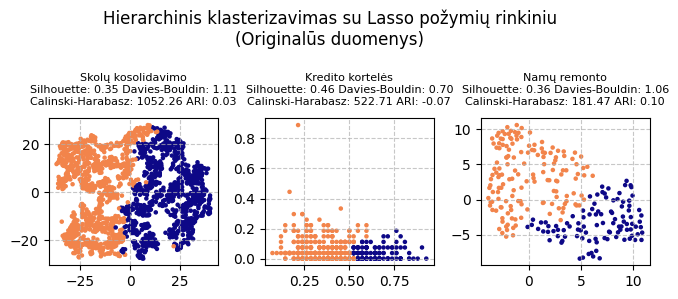

In [196]:
labels_debt = fcluster(wards_clustering_debt_lasso, t=2, criterion='maxclust')
labels_credit = fcluster(wards_clustering_credit_lasso, t=2, criterion='maxclust')
labels_home = fcluster(wards_clustering_home_lasso, t=2, criterion='maxclust')

true_labels = [lasso_debt['credit.policy'],
               lasso_credit['credit.policy'],
               lasso_home['credit.policy']]

tsne_results = [lasso_debt_tsne, lasso_credit_tsne, lasso_home_tsne]
labels = [labels_debt, labels_credit, labels_home]

fig, axes = plt.subplots(1, 3, figsize=(6.7, 3))
categories = ['debt_consolidation', 'credit_card', 'home_improvement']

scores = all_scores([full_feature_dfs['debt_consolidation'], full_feature_dfs['credit_card'], full_feature_dfs['home_improvement']],
                    [labels_debt, labels_credit, labels_home], true_labels)

for i, cat in enumerate(categories):
    subset = tsne_results[i]
    label = labels[i]
    
    axes[i].scatter(subset[:, 0], subset[:, 1], c=label, cmap=plasma_truncated, s=5)
    title_text = f"{group_names[i]}\nSilhouette: {scores[i][0]:.2f} Davies-Bouldin: {scores[i][1]:.2f}\nCalinski-Harabasz: {scores[i][2]:.2f} ARI: {scores[i][3]:.2f}"
    axes[i].set_title(title_text, fontsize=8, pad=10)
    axes[i].grid(True, linestyle='--', alpha=0.7)

plt.suptitle("Hierarchinis klasterizavimas su Lasso požymių rinkiniu\n(Originalūs duomenys)")
plt.tight_layout()
plt.savefig('hier_lasso.png', dpi=300)
plt.show()

In [197]:
row_labels = ['Siluetas', 'DB', 'CH', 'ARI']
pd.DataFrame({group_names[i]: [round(scores[i][j], 2) for j in range(4)] for i in range(3)}, index=row_labels)

,Skolų kosolidavimo,Kredito kortelės,Namų remonto
Siluetas,0.35,0.46,0.36
DB,1.11,0.70,1.06
CH,1052.26,522.71,181.47
ARI,0.03,-0.07,0.10


## t-SNE

In [198]:
full_feature_dfs = {
    'debt_consolidation': lasso_debt_tsne,
    'credit_card': lasso_credit_tsne,
    'home_improvement': lasso_home_tsne,
}

wards_clustering_debt_lasso_tsne = linkage(full_feature_dfs['debt_consolidation'], method="ward", metric="euclidean")
wards_clustering_credit_lasso_tsne = linkage(full_feature_dfs['credit_card'], method="ward", metric="euclidean")
wards_clustering_home_lasso_tsne = linkage(full_feature_dfs['home_improvement'], method="ward", metric="euclidean")

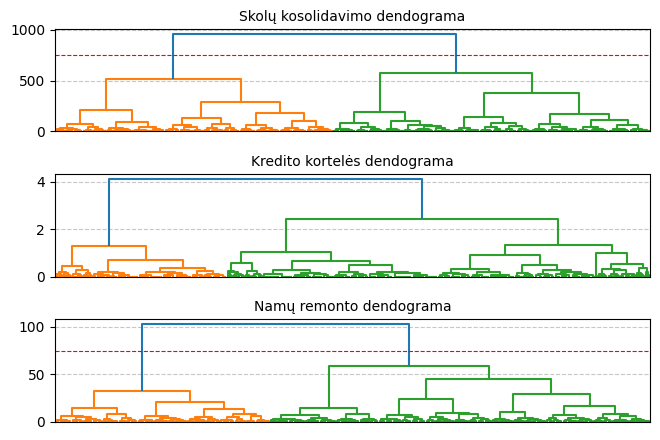

In [199]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(6.7, 4.5))

axes = [ax1, ax2, ax3]
linkages = [wards_clustering_debt_lasso_tsne, wards_clustering_credit_lasso_tsne, wards_clustering_home_lasso_tsne]
cut_offs = [750, 11000, 75]
group_names = ["Skolų kosolidavimo", "Kredito kortelės", "Namų remonto"]

for ax, link, h, gm in zip(axes, linkages, cut_offs, group_names):
    dendrogram(link, ax=ax)
    
    ax.set_xticks([])
    ax.axhline(y=h, color='r', linestyle='--', linewidth = 0.8)
    ax.grid(True, axis='y', linestyle='--', alpha=0.7)

    ax.set_title(f"{gm} dendograma", size = 10)

plt.tight_layout()
plt.savefig('hier_lasso_dendo_tsne.png', dpi=300)
plt.show()

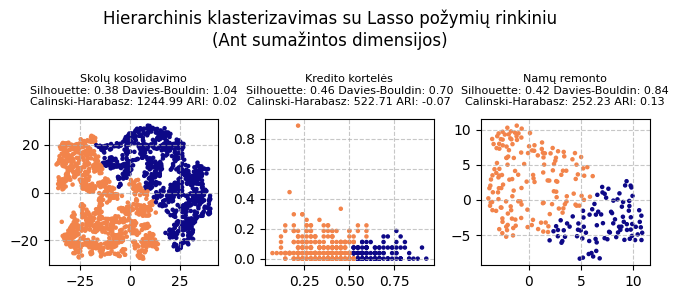

In [200]:
labels_debt = fcluster(wards_clustering_debt_lasso_tsne, t=2, criterion='maxclust')
labels_credit = fcluster(wards_clustering_credit_lasso_tsne, t=2, criterion='maxclust')
labels_home = fcluster(wards_clustering_home_lasso_tsne, t=2, criterion='maxclust')

true_labels = [lasso_debt['credit.policy'],
               lasso_credit['credit.policy'],
               lasso_home['credit.policy']]

tsne_results = [lasso_debt_tsne, lasso_credit_tsne, lasso_home_tsne]
labels = [labels_debt, labels_credit, labels_home]

fig, axes = plt.subplots(1, 3, figsize=(6.7, 3))
categories = ['debt_consolidation', 'credit_card', 'home_improvement']

scores = all_scores([full_feature_dfs['debt_consolidation'], full_feature_dfs['credit_card'], full_feature_dfs['home_improvement']],
                    [labels_debt, labels_credit, labels_home], true_labels)

for i, cat in enumerate(categories):
    subset = tsne_results[i]
    label = labels[i]
    
    axes[i].scatter(subset[:, 0], subset[:, 1], c=label, cmap=plasma_truncated, s=5)
    title_text = f"{group_names[i]}\nSilhouette: {scores[i][0]:.2f} Davies-Bouldin: {scores[i][1]:.2f}\nCalinski-Harabasz: {scores[i][2]:.2f} ARI: {scores[i][3]:.2f}"
    axes[i].set_title(title_text, fontsize=8, pad=10)
    axes[i].grid(True, linestyle='--', alpha=0.7)

plt.suptitle("Hierarchinis klasterizavimas su Lasso požymių rinkiniu\n(Ant sumažintos dimensijos)")
plt.tight_layout()
plt.savefig('hier_lasso_tsne.png', dpi=300)
plt.show()

In [201]:
row_labels = ['Siluetas', 'DB', 'CH', 'ARI']
pd.DataFrame({group_names[i]: [round(scores[i][j], 2) for j in range(4)] for i in range(3)}, index=row_labels)

,Skolų kosolidavimo,Kredito kortelės,Namų remonto
Siluetas,0.38,0.46,0.42
DB,1.04,0.70,0.84
CH,1244.99,522.71,252.23
ARI,0.02,-0.07,0.13


---

In [202]:
clustering_stability(10, lasso_debt.iloc[:,:-1], 2)

Vidutinis klasterių stabilumas (ARI): 0.469
Stabilumo standartinis nuokrypis: 0.179


In [203]:
clustering_stability(10, lasso_credit.iloc[:,:-1], 2)

Vidutinis klasterių stabilumas (ARI): 0.591
Stabilumo standartinis nuokrypis: 0.230


In [204]:
clustering_stability(10, lasso_home.iloc[:,:-1], 2)

Vidutinis klasterių stabilumas (ARI): 0.381
Stabilumo standartinis nuokrypis: 0.218
